In [2]:
from amoc_analysis import data, plotting
import amocatlas
from spectra_filtering import analysis, data_io, filters, leakage, spectra
from amocatlas import read

In [3]:
from scipy import signal
from scipy.stats import chi2
import matplotlib.pyplot as plt
import numpy as np

In [4]:
import importlib

importlib.reload(spectra)

<module 'spectra_filtering.spectra' from 'C:\\Users\\Isabelle\\Documents\\GitHub\\data_analysis-assignment\\spectra_filtering\\spectra.py'>

## Read OSNAP data

In [5]:
ds = read.osnap()

Loading 1 OSNAP dataset(s):
  0. OSNAP_MOC_MHT_MFT_TimeSeries_201408_202207_2025.nc: Time series of MOC, MHT, and MFT (2014-2022)



## Explore stats

In [6]:
moc = ds["MOC_EAST_SIGMA0"]

In [7]:
analysis.summary_stats(moc)

{'n': 96,
 'n_missing': <xarray.DataArray 'MOC_EAST_SIGMA0' ()> Size: 8B
 array(0)
 Attributes:
     long_name:         Eastern MOC_sigma0
     units:             Sverdrup
     QC_indicatoris:    good data
     processing_level:  data manually reviewed
     comment:           maximum of the overturning streamfunction in sigma_the...
     description:       Maximum overturning streamfunction across OSNAP East
     standard_name:     ocean_meridional_overturning_streamfunction,
 'mean': np.float64(16.351453296346662),
 'std': np.float64(2.907178078280368),
 'median': np.float64(16.191231819090753),
 'min': np.float64(10.359161634530988),
 'max': np.float64(23.658947304273145),
 'range': np.float64(13.299785669742157)}

- discovered this function after i did all of this manually for the `osnap_characteristics.ipynb`
- shows the general structure of the dataset 
- here the dataset is again OSNAP EAST MOC

### define spectra values

In [8]:
x = moc.interpolate_na("TIME").values
fs = 1 / 30
series_raw = np.asarray(x)
series = series_raw[np.isfinite(series_raw)]
time_years = np.arange(series_raw.size) / fs / 365.25

- we interpolate the time variable to not have any gaps 
- here we don't have any gaps to start with so this is a little bit of an uneccessary step, but if this code would be used for a dataset which does have gaps then this step is essential (because this analysis only works with a continuous time variable)

### calculate periodogram and welch 

In [9]:
periodogram = spectra.raw_periodogram(
    series,
    dt_days=30,
    detrend="linear",
)
f_p_spectra = periodogram[0]
Pxx_p_spectra = periodogram[1]

- here we calculate the periodogram with the function defined in the `spectra.py`module 
- then i define the periodogram spectra values and the power spectral density from the dictionary returned by the function
- the function defaults to a 'boxcar' window

In [10]:
# define segment length and overlap for Welch's method
nperseg = 36
# min(96, series.size)
overlap = max(0, nperseg // 2)

- now we define the segment length 
- as we have monthly data the segment length cannot be so long (as in the RAPID example)
- therefore our length is 96 
- then naturally our overlap is half as much, so 48


In [11]:
# welch from spectra.py module
# here defining no overlap results in using half of the segment length as overlap value
welch_psd = spectra.welch_psd(
    series,
    dt_days=30,
    segment_length=nperseg,
    window="hann",
)

In [12]:
# generate welch for multiple nperseg values

for n in [12, 24, 36, 48, 96]:
    welch_psd[n] = spectra.welch_psd(
        series,
        dt_days=30,
        segment_length=n,
        window="hann",
    )

In [13]:
welch_psd[12]

{'freq': array([0.        , 0.00277778, 0.00555556, 0.00833333, 0.01111111,
        0.01388889, 0.01666667]),
 'psd': array([ 93.73877448, 491.7522431 , 367.9607362 , 230.60339348,
        313.42677726, 275.48043894, 121.71280425]),
 'lo': np.float64(0.6385799039583588),
 'hi': np.float64(1.7866956638749698)}

- now we use the function `welch_psd` from `spectra.py` to calculate our welch spectrum 
- we define our window to be 'hann' because of leakage and tapering (is nicer with frequencies, could also do tukey though i think)
- the overlap here defaults to half of the segment_length defined, which is what i wanted - therefore i did not specify it in the function here
- the input dt_days is the sampling frequency which is then used in both the original `signal.periodogram` and `signal.welch` function as `fs = 1/dt_days`.


In [14]:
# extracting values from dictionary returned by welch_psd function
Pxx_w_spectra = welch_psd["psd"]
f_w_spectra = welch_psd["freq"]
hi_w = welch_psd["hi"]
lo_w = welch_psd["lo"]

### define comparsion values for parseval

In [15]:
# parseval ratio
ratio = spectra.parseval_ratio(series, f_w_spectra, Pxx_w_spectra)
ratio

0.8731810114278323

- here the parseval ratio is calculated 
- our magical way of seeing if iour calcualtions/code actually make sense
- it relates the time and frequency domain 
- here it basically says that the variance iof our variable in the time domain is the same as the integral of our psd and frequency in the frequency domain

## define plotting values

In [16]:
# length of frequency steps
df_p = f_p_spectra[1] - f_p_spectra[0]
df_w = f_w_spectra[1] - f_w_spectra[0]

# variance in time domain
var_time = np.var(series)

# variance in frequency domain
var_p = np.sum(Pxx_p_spectra) * df_p
var_w = np.sum(Pxx_w_spectra) * df_w

# frequency steps in cycles per year
freq_p = f_p_spectra[1:] * 365.25
freq_w = f_w_spectra[1:] * 365.25

# power spectral density values for plotting (excluding the zero frequency component)
Pxx_p_plot = Pxx_p_spectra[1:]
Pxx_w_plot = Pxx_w_spectra[1:]

# confidence intervals for Welch's method
segments = max(1, 1 + max(0, series.size - nperseg) // max(1, nperseg - overlap))
dof = 2 * segments
lo = dof / chi2.ppf(0.975, dof)
hi = dof / chi2.ppf(0.025, dof)

In [17]:
dof

8

### plot spectrum

OSNAP variance: time domain = 8.3636, periodogram = 8.3387, Welch = 7.4845, parseval ratio = 0.8732


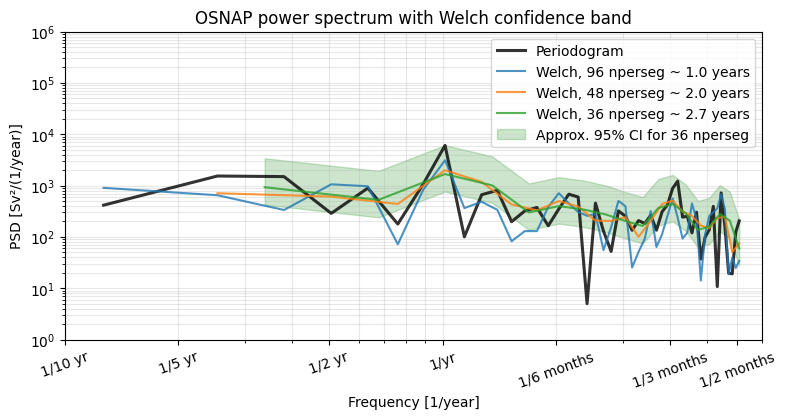

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))

# plot periodogram
ax.loglog(
    freq_p, Pxx_p_plot, label="Periodogram", color="black", alpha=0.8, linewidth=2.2
)

# plot Welch's method with confidence intervals
for n in [96, 48, 36]:
    freq_w_n = welch_psd[n]["freq"][1:] * 365.25
    Pxx_w_n = welch_psd[n]["psd"][1:]
    ax.loglog(
        freq_w_n, Pxx_w_n, label=f"Welch, {n} nperseg ~ {96 / n:.1f} years", alpha=0.8
    )

# ax.loglog(freq_w, Pxx_w_plot, label=f'Welch, {nperseg} nperseg ~ {96/nperseg:.1f} years')
ax.fill_between(
    freq_w,
    Pxx_w_plot * lo,
    Pxx_w_plot * hi,
    color="green",
    alpha=0.2,
    label="Approx. 95% CI for 36 nperseg",
)

# adjust plotting parameters
ax.set_title("OSNAP power spectrum with Welch confidence band")
ax.set_xlabel("Frequency [1/year]")
# set ylabel with units of power spectral density (PSD)
ax.set_ylabel("PSD [Sv²/(1/year)]")
axis_max = max(float(np.nanmax(freq_p)), float(np.nanmax(freq_w)))
ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 4, 6, 12, 52])
ax.set_xticklabels(
    [
        "1/10 yr",
        "1/5 yr",
        "1/2 yr",
        "1/yr",
        "1/6 months",
        "1/3 months",
        "1/2 months",
        "1/month ",
        "1/wk",
    ],
    rotation=20,
)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
ax.set_ylim(1, 1e6)
ax.set_xlim(1e-1, 7)

# print check of variance values (parseval)
print(
    f"OSNAP variance: time domain = {var_time:.4f}, periodogram = {var_p:.4f}, Welch = {var_w:.4f}, parseval ratio = {ratio:.4f}"
)

- weirdly there is no rolloff 
- we do see the increased peak for the annual variability
- an another smaller peak for 3 monthly variability
- is there no rolloff because we do not have any signals lower than a month (because of the resolution)?
- segment length determines what signals we see 
- data is just monthly and there is no filter applied

## filtered timeseries 

In [34]:
moc

<xarray.DataArray 'MOC_EAST_SIGMA0' (TIME: 96)> Size: 768B
array([13.957641, 11.58589 , 16.939049, 14.30638 , 10.359162, 16.371932,
       14.888799, 14.916052, 21.593433, 19.948054, 23.395896, 21.21311 ,
       19.645884, 16.821249, 19.703452, 14.755354, 15.351777, 17.849446,
       18.120667, 15.776076, 21.570685, 19.544237, 15.161247, 14.885939,
       17.759935, 17.788474, 16.483337, 17.526148, 12.887264, 14.054406,
       18.569429, 18.908384, 21.382383, 17.126113, 15.308407, 10.839754,
       17.266958, 14.697471, 14.575389, 11.806158, 12.62369 , 17.194061,
       13.981155, 18.894096, 16.036115, 18.700981, 16.482601, 13.824016,
       17.640977, 15.704319, 13.880557, 16.290297, 16.455916, 13.988822,
       17.244296, 15.285588, 15.421521, 17.191683, 15.190785, 12.992227,
       14.140949, 15.272656, 13.693274, 11.862828, 11.333426, 16.092167,
       16.872851, 18.293077, 18.742275, 22.948554, 22.789452, 17.545262,
       18.567847, 14.114407, 14.053032, 16.513514, 13.850674, 15.972017,
       23.658947, 18.661336, 19.419706, 17.993354, 14.145359, 15.475973,
       17.302052, 14.589146, 13.315129, 13.752371, 13.580009, 12.347214,
       15.908456, 11.143922, 17.960571, 17.356402, 18.596677, 21.209506])
Coordinates:
  * TIME     (TIME) datetime64[ns] 768B 2014-08-01T12:00:00 ... 2022-07-01T12...
Attributes:
    long_name:         Eastern MOC_sigma0
    units:             Sverdrup
    QC_indicatoris:    good data
    processing_level:  data manually reviewed
    comment:           maximum of the overturning streamfunction in sigma_the...
    description:       Maximum overturning streamfunction across OSNAP East
    standard_name:     ocean_meridional_overturning_streamfunction

In [39]:
window = 12
moc_filt = filters.tukey_lowpass(moc, window=window)

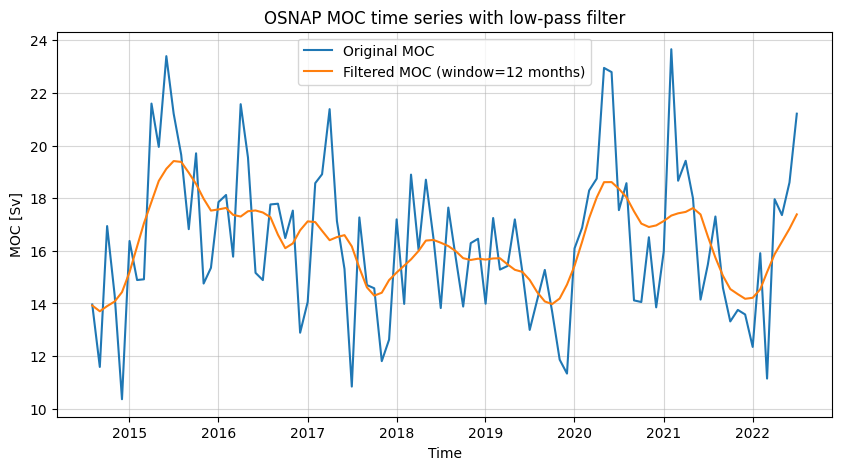

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(moc.TIME, moc, label="Original MOC")
plt.plot(moc.TIME, moc_filt, label=f"Filtered MOC (window={window} months)")
plt.title("OSNAP MOC time series with low-pass filter")
plt.xlabel("Time")
plt.ylabel("MOC [Sv]")
plt.grid(alpha=0.5)
plt.legend()

## boxcar

In [40]:
import pandas as pd

In [63]:
s = pd.Series(moc, index=moc.TIME)


In [64]:
s

2014-08-01 12:00:00    13.957641
2014-09-01 12:00:00    11.585890
2014-10-01 12:00:00    16.939049
2014-11-01 12:00:00    14.306380
2014-12-01 12:00:00    10.359162
                         ...    
2022-03-01 12:00:00    11.143922
2022-04-01 12:00:00    17.960571
2022-05-01 12:00:00    17.356402
2022-06-01 12:00:00    18.596677
2022-07-01 12:00:00    21.209506
Length: 96, dtype: float64

In [65]:
box = s.rolling(12, center=True, win_type="boxcar", min_periods =1).mean()
tuk = s.rolling(12, center=True, win_type="tukey", min_periods =1).mean()

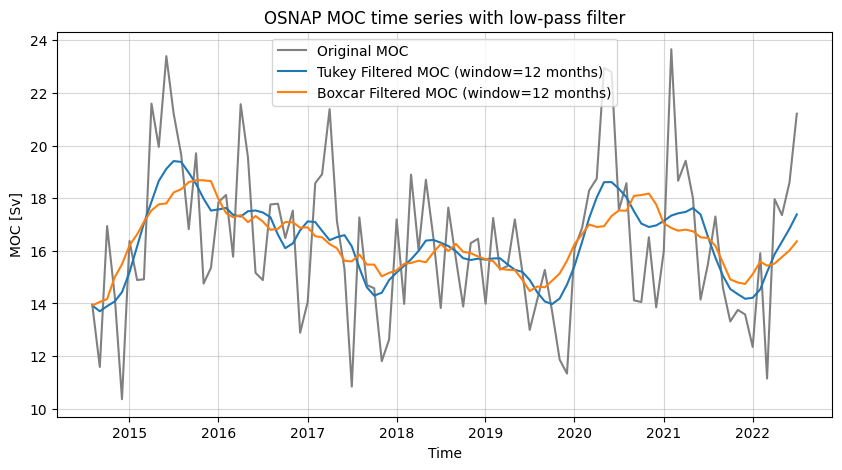

In [69]:
plt.figure(figsize=(10, 5))
plt.title("OSNAP MOC time series with low-pass filter")
plt.xlabel("Time")
plt.ylabel("MOC [Sv]")
plt.plot(s, label="Original MOC", color = "grey")
plt.plot(tuk, label="Tukey Filtered MOC (window=12 months)")
plt.plot(box, label="Boxcar Filtered MOC (window=12 months)")
plt.grid(alpha=0.5)
plt.legend()

## can i do spectra analysis with the new timeseries?

In [21]:
ds["MOC_FILT"] = (("TIME"), moc_filt)

In [22]:
moc_filt = ds.MOC_FILT

In [23]:
x = moc_filt.interpolate_na("TIME").values
fs = 1 / 30
series_raw = np.asarray(x)
series = series_raw[np.isfinite(series_raw)]
time_years = np.arange(series_raw.size) / fs / 365.25

In [24]:
periodogram = spectra.raw_periodogram(
    series,
    dt_days=30,
    detrend="linear",
)
f_p_spectra = periodogram[0]
Pxx_p_spectra = periodogram[1]

In [25]:
for n in [12, 24, 36, 48, 96]:
    welch_psd[n] = spectra.welch_psd(
        series,
        dt_days=30,
        segment_length=n,
        window="hann",
    )

In [26]:
ratio = spectra.parseval_ratio(series, f_w_spectra, Pxx_w_spectra)
ratio

3.6324920663709723

In [27]:
# length of frequency steps
df_p = f_p_spectra[1] - f_p_spectra[0]
df_w = f_w_spectra[1] - f_w_spectra[0]

# variance in time domain
var_time = np.var(series)

# variance in frequency domain
var_p = np.sum(Pxx_p_spectra) * df_p
var_w = np.sum(Pxx_w_spectra) * df_w

# frequency steps in cycles per year
freq_p = f_p_spectra[1:] * 365.25
freq_w = f_w_spectra[1:] * 365.25

# power spectral density values for plotting (excluding the zero frequency component)
Pxx_p_plot = Pxx_p_spectra[1:]
Pxx_w_plot = Pxx_w_spectra[1:]

# confidence intervals for Welch's method
segments = max(1, 1 + max(0, series.size - nperseg) // max(1, nperseg - overlap))
dof = 2 * segments
lo = dof / chi2.ppf(0.975, dof)
hi = dof / chi2.ppf(0.025, dof)

OSNAP variance: time domain = 2.0105, periodogram = 1.9707, Welch = 7.4845, parseval ratio = 3.6325


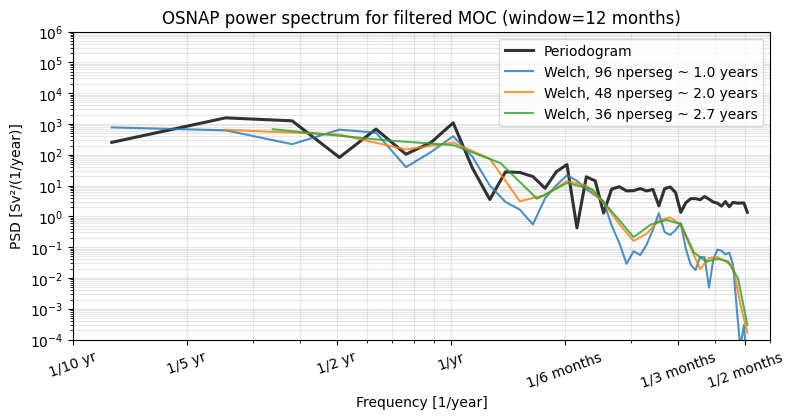

In [28]:
fig, ax = plt.subplots(figsize=(9, 4))

# plot periodogram
ax.loglog(
    freq_p, Pxx_p_plot, label="Periodogram", color="black", alpha=0.8, linewidth=2.2
)

# plot Welch's method with confidence intervals
for n in [96, 48, 36]:
    freq_w_n = welch_psd[n]["freq"][1:] * 365.25
    Pxx_w_n = welch_psd[n]["psd"][1:]
    ax.loglog(
        freq_w_n, Pxx_w_n, label=f"Welch, {n} nperseg ~ {96 / n:.1f} years", alpha=0.8
    )

# ax.loglog(freq_w, Pxx_w_plot, label=f'Welch, {nperseg} nperseg ~ {96/nperseg:.1f} years')
# ax.fill_between(
#     freq_w,
#     Pxx_w_plot * lo,
#     Pxx_w_plot * hi,
#     color='green',
#     alpha=0.2,
#     label='Approx. 95% CI for 36 nperseg',
# )

# adjust plotting parameters
ax.set_title(f"OSNAP power spectrum for filtered MOC (window={window} months)")
ax.set_xlabel("Frequency [1/year]")
# set ylabel with units of power spectral density (PSD)
ax.set_ylabel("PSD [Sv²/(1/year)]")
axis_max = max(float(np.nanmax(freq_p)), float(np.nanmax(freq_w)))
ax.set_xticks([0.1, 0.2, 0.5, 1, 2, 4, 6, 12, 52])
ax.set_xticklabels(
    [
        "1/10 yr",
        "1/5 yr",
        "1/2 yr",
        "1/yr",
        "1/6 months",
        "1/3 months",
        "1/2 months",
        "1/month ",
        "1/wk",
    ],
    rotation=20,
)
ax.grid(True, which="both", alpha=0.3)
ax.legend()

ax.set_ylim(1e-4, 1e6)
ax.set_xlim(1e-1, 7)

# print check of variance values (parseval)
print(
    f"OSNAP variance: time domain = {var_time:.4f}, periodogram = {var_p:.4f}, Welch = {var_w:.4f}, parseval ratio = {ratio:.4f}"
)